In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('../data/sample_car_contracts.csv')
df

,id,customer_name,contract_type,vehicle_type,monthly_emi,interest_rate,tenure_months,clause_summary,risk_flag,issue_type,recommended_action
0,1,Rahul Mehta,Car Loan,Sedan,18500,9.5,48,Prepayment allowed only after 24 months with 5...,medium,High prepayment charges,Highlight prepayment penalty to user and sugge...
1,2,Anita Rao,Car Lease,SUV,22000,0.0,36,Lessee must pay for all maintenance and insurance,low,Standard maintenance clause,"No action, just explain maintenance responsibi..."
2,3,James Wilson,Car Loan,Hatchback,14500,11.2,60,Late payment fee of 3% per month on outstandin...,high,Aggressive late fee,Flag clause and suggest user request cap on la...
3,4,Meena Iyer,Car Lease,Sedan,21000,0.0,24,"Excess mileage charge of ₹12 per km over 15,00...",medium,High excess mileage rate,Warn user about extra mileage charges and reco...
4,5,Arjun Patel,Car Loan,SUV,27500,10.8,72,Floating interest rate linked to lender's inte...,high,Unclear interest benchmark,Explain floating rate risk and suggest asking ...
5,6,Sana Khan,Car Lease,Hatchback,16500,0.0,36,Early termination fee equal to 6 months of EMI,high,Heavy early termination penalty,Flag as risky and suggest negotiating lower te...
6,7,Vikram Shah,Car Loan,Sedan,19500,8.9,36,No foreclosure charges after 12 months,low,User friendly foreclosure policy,"Mark as positive clause, no action required"
7,8,Neha Singh,Car Lease,EV,25500,0.0,48,Battery warranty covered only for 24 months or...,medium,Limited EV battery warranty,Warn user about battery risk and suggest exten...
8,9,David Roy,Car Loan,SUV,30500,12.5,84,Mandatory bundled insurance from lender at non...,high,Forced insurance bundling,Flag as unfair tying and suggest independent i...
9,10,Kiran Kumar,Car Lease,Sedan,18500,0.0,30,"Security deposit of 3 EMIs, refundable at end ...",low,Standard security deposit,"Explain condition for refund, low risk"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  12 non-null     int64  
 1   customer_name       12 non-null     object 
 2   contract_type       12 non-null     object 
 3   vehicle_type        12 non-null     object 
 4   monthly_emi         12 non-null     int64  
 5   interest_rate       12 non-null     float64
 6   tenure_months       12 non-null     int64  
 7   clause_summary      12 non-null     object 
 8   risk_flag           12 non-null     object 
 9   issue_type          12 non-null     object 
 10  recommended_action  12 non-null     object 
dtypes: float64(1), int64(3), object(7)
memory usage: 1.2+ KB


In [5]:
df.columns

Index(['id', 'customer_name', 'contract_type', 'vehicle_type', 'monthly_emi',
       'interest_rate', 'tenure_months', 'clause_summary', 'risk_flag',
       'issue_type', 'recommended_action'],
      dtype='object')

In [6]:

bar_df = df.groupby('risk_flag')['interest_rate'].mean().reset_index()
bar_df


,risk_flag,interest_rate
0,high,6.900000
1,low,2.966667
2,medium,4.850000


In [13]:
df.columns

Index(['id', 'customer_name', 'contract_type', 'vehicle_type', 'monthly_emi',
       'interest_rate', 'tenure_months', 'clause_summary', 'risk_flag',
       'issue_type', 'recommended_action'],
      dtype='object')

In [18]:
print("The Customer Count is : ",df["customer_name"].count())

The Customer Count is :  12


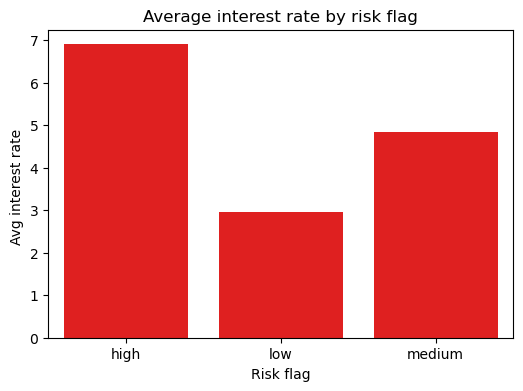

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(x='risk_flag', y='interest_rate', data=bar_df,color="Red")
plt.title('Average interest rate by risk flag')
plt.xlabel('Risk flag')
plt.ylabel('Avg interest rate ')
plt.show()

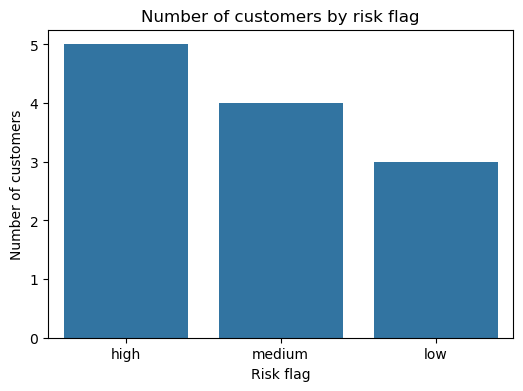

In [8]:
count_df = df['risk_flag'].value_counts().reset_index()
count_df.columns = ['risk_flag', 'customer_count']

plt.figure(figsize=(6,4))
sns.barplot(x='risk_flag', y='customer_count', data=count_df)
plt.title('Number of customers by risk flag')
plt.xlabel('Risk flag')
plt.ylabel('Number of customers')
plt.show()

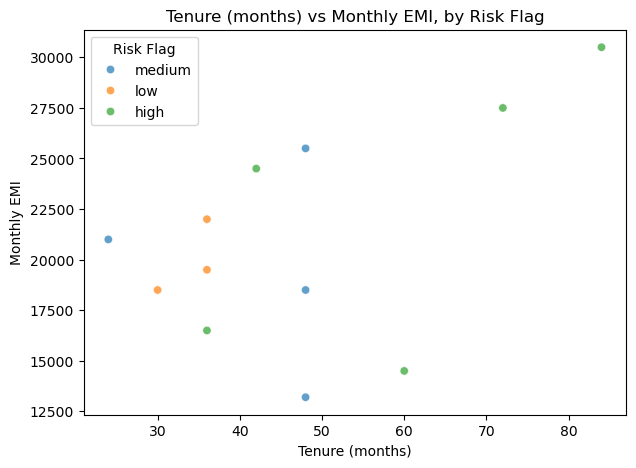

In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='tenure_months', y='monthly_emi', hue='risk_flag', data=df, alpha=0.7)
plt.title('Tenure (months) vs Monthly EMI, by Risk Flag')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly EMI')
plt.legend(title='Risk Flag')
plt.show()

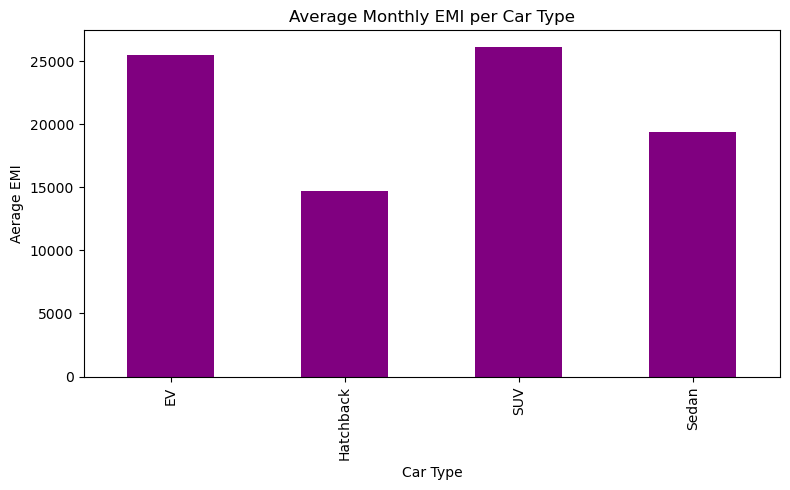

In [21]:
plt.figure(figsize=(8,5))
df.groupby('vehicle_type')['monthly_emi'].mean().plot(kind='bar',color='purple')
plt.title("Average Monthly EMI per Car Type")
plt.xlabel("Car Type")
plt.ylabel("Aerage EMI")
plt.tight_layout()
plt.show()

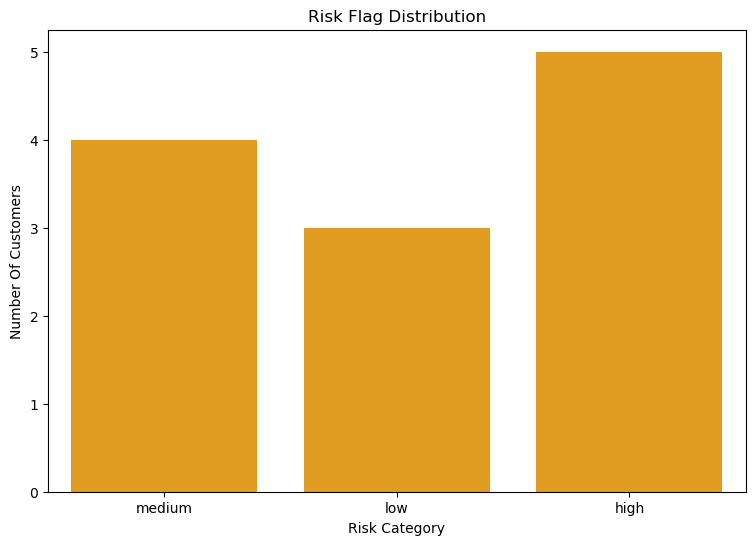

In [24]:

plt.figure(figsize=(9,6))
sns.countplot(data=df, x="risk_flag",color="Orange")
plt.title("Risk Flag Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number Of Customers")
plt.show()

In [29]:
df["tenure_years"] = df["tenure_months"] / 12
df["total_amount"] = df["monthly_emi"] * df["tenure_months"]

avg_total = df["total_amount"].mean()
avg_emi = df["monthly_emi"].mean()
avg_tenure = df["tenure_years"].mean()

print(df[["tenure_years", "total_amount"]].head())

print("\nAverage total amount by risk_flag:\n", avg_total)
print("\nAverage EMI by risk_flag:\n", avg_emi)
print("\nAverage tenure (years) by risk_flag:\n", avg_tenure)

print("\nCrosstab of risk_flag vs recommended_action:\n", 
      pd.crosstab(df["risk_flag"], df["recommended_action"]))


   tenure_years  total_amount
0           4.0        888000
1           3.0        792000
2           5.0        870000
3           2.0        504000
4           6.0       1980000

Average total amount by risk_flag:
 1027800.0

Average EMI by risk_flag:
 20975.0

Average tenure (years) by risk_flag:
 3.9166666666666665

Crosstab of risk_flag vs recommended_action:
 recommended_action  Explain condition for refund, low risk  \
risk_flag                                                    
high                                                     0   
low                                                      1   
medium                                                   0   

recommended_action  Explain floating rate risk and suggest asking for external benchmark or cap  \
risk_flag                                                                                         
high                                                                1                             
low                     